# Part B: Mathematics, Statistics, and Optimization
This notebook covers linear algebra, gradient descent, statistics, probability, distributions, and loss functions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

## B1: Linear Algebra
This cell creates vectors and matrices, performs core operations, and reports the shape of every result.

In [2]:
vector_a = np.array([1, 2, 3])
vector_b = np.array([4, 5, 6])
matrix_a = np.array([[1, 2, 3], [4, 5, 6]])
matrix_b = np.array([[1, 2], [3, 4], [5, 6]])
results = {'addition': vector_a + vector_b, 'scalar multiplication': 2 * vector_a, 'dot product': np.dot(vector_a, vector_b), 'matrix multiplication': matrix_a @ matrix_b, 'transpose': matrix_a.T}
for name, result in results.items():
    print(f'{name}: {result}; shape={np.shape(result)}')

addition: [5 7 9]; shape=(3,)
scalar multiplication: [2 4 6]; shape=(3,)
dot product: 32; shape=()
matrix multiplication: [[22 28]
 [49 64]]; shape=(2, 2)
transpose: [[1 4]
 [2 5]
 [3 6]]; shape=(3, 2)


Addition and scalar multiplication preserve vector shape. The dot product is a scalar, matrix multiplication creates a new matrix, and transpose exchanges rows and columns.

Element-wise multiplication multiplies matching positions. Matrix multiplication combines rows and columns by summing products; the same two arrays make the contrast clear.

In [3]:
left = np.array([[1, 2], [3, 4]])
right = np.array([[5, 6], [7, 8]])
print('Element-wise multiplication:\n', left * right)
print('Matrix multiplication:\n', left @ right)

Element-wise multiplication:
 [[ 5 12]
 [21 32]]
Matrix multiplication:
 [[19 22]
 [43 50]]


The element-wise operation keeps each location independent. Matrix multiplication aggregates information across rows and columns, which is the operation used by linear models.

For linear-model predictions, X has shape (n_samples, n_features), w has shape (n_features,), and X @ w produces one prediction per sample. X column count must equal w length so every feature has one weight.

In [4]:
X = np.array([[1., 2., 3.], [4., 5., 6.], [7., 8., 9.]])
w = np.array([0.5, -1., 2.])
predictions = X @ w
print(f'X shape: {X.shape}')
print(f'w shape: {w.shape}')
print(f'predictions shape: {predictions.shape}')
print(predictions)

X shape: (3, 3)
w shape: (3,)
predictions shape: (3,)
[ 4.5  9.  13.5]


X is (3, 3), w is (3,), and predictions is (3,). Each row in X becomes one weighted prediction.

## B2: Derivatives and Gradient Descent
The next data set follows the noisy relationship y = 3x + 5.

In [5]:
n_samples = 200
x_values = np.random.uniform(-5, 5, n_samples)
y_values = 3 * x_values + 5 + np.random.normal(0, 1, n_samples)

Mean squared error is

$$\operatorname{MSE}(w,b)=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2, \qquad \hat{y}_i=wx_i+b.$$

It is the average squared distance between predictions and targets.

Differentiating MSE gives

$$\frac{\partial \operatorname{MSE}}{\partial w}=\frac{1}{n}\sum_i2(\hat{y}_i-y_i)\frac{\partial(wx_i+b)}{\partial w}=\frac{2}{n}\sum_i(\hat{y}_i-y_i)x_i,$$

$$\frac{\partial \operatorname{MSE}}{\partial b}=\frac{1}{n}\sum_i2(\hat{y}_i-y_i)\frac{\partial(wx_i+b)}{\partial b}=\frac{2}{n}\sum_i(\hat{y}_i-y_i).$$

Gradient descent subtracts a learning-rate-scaled version of these gradients.

In [6]:
weight = 0.0
bias = 0.0
learning_rate = 0.05
loss_history = []
for _ in range(500):
    current_predictions = weight * x_values + bias
    errors = current_predictions - y_values
    loss_history.append(np.mean(errors ** 2))
    weight -= learning_rate * 2 * np.mean(errors * x_values)
    bias -= learning_rate * 2 * np.mean(errors)

This plot demonstrates whether NumPy-only gradient descent steadily reduces the MSE objective.

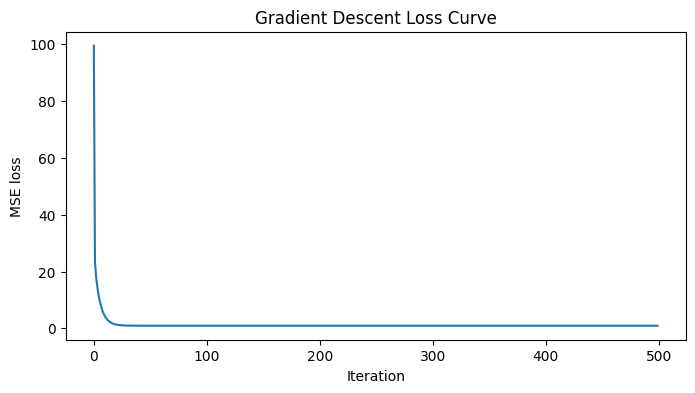

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE loss')
plt.title('Gradient Descent Loss Curve')
plt.show()

The curve drops quickly then levels off, indicating convergence near the best linear fit for this noisy data.

This cell compares the from-scratch solution with LinearRegression fitted to the same samples.

In [8]:
from sklearn.linear_model import LinearRegression
sklearn_model = LinearRegression().fit(x_values.reshape(-1, 1), y_values)
print(f'Gradient descent: weight={weight:.4f}, bias={bias:.4f}')
print(f'LinearRegression: weight={sklearn_model.coef_[0]:.4f}, bias={sklearn_model.intercept_:.4f}')

Gradient descent: weight=2.9922, bias=5.0662
LinearRegression: weight=2.9922, bias=5.0662


Both parameter sets should be close because they minimize the same MSE. Small differences can come from finite iterations and the learning rate.

## B3: Statistics
This summary computes common measures of center, spread, and association.

The following output reports mean, median, variance, standard deviation, covariance, and correlation for two variables.

In [9]:
second_variable = 2 * x_values + np.random.normal(0, 2, n_samples)
print(f'Mean: {np.mean(x_values):.3f}')
print(f'Median: {np.median(x_values):.3f}')
print(f'Variance: {np.var(x_values):.3f}')
print(f'Standard deviation: {np.std(x_values):.3f}')
print(f'Covariance: {np.cov(x_values, second_variable)[0, 1]:.3f}')
print(f'Correlation: {np.corrcoef(x_values, second_variable)[0, 1]:.3f}')

Mean: -0.160
Median: -0.055
Variance: 8.653
Standard deviation: 2.942
Covariance: 17.679
Correlation: 0.948


Mean and median describe central tendency; variance and standard deviation describe spread. Covariance shows whether values move together, while correlation normalizes that association to the interval from -1 to 1.

This example injects one large outlier into otherwise ordinary values to compare mean and median.

In [10]:
ordinary_values = np.array([9, 10, 10, 11, 10, 9, 11])
values_with_outlier = np.append(ordinary_values, 100)
print(f'Mean: {np.mean(values_with_outlier):.2f}')
print(f'Median: {np.median(values_with_outlier):.2f}')
print(f'Variance: {np.var(values_with_outlier):.2f}')
print(f'Standard deviation: {np.std(values_with_outlier):.2f}')

Mean: 21.25
Median: 10.00
Variance: 886.44
Standard deviation: 29.77


The outlier pulls the mean far above the median because the mean uses every magnitude. The median stays near typical values, while variance and standard deviation increase sharply.

## B4: Probability
These examples calculate conditional probability, independence, Bayes theorem, and classification error probabilities.

This small sample-space example calculates P(even given greater than 3) for a fair die.

In [11]:
outcomes = np.arange(1, 7)
event_a = outcomes % 2 == 0
event_b = outcomes > 3
print(f'P(even | greater than 3) = {np.sum(event_a & event_b) / np.sum(event_b):.2f}')

P(even | greater than 3) = 0.67


Among 4, 5, and 6, two values are even, so the conditional probability is 2/3.

Two fair coin flips are independent; drawing two cards without replacement is not. This cell compares the product rule in both cases.

In [12]:
p_two_heads = 0.25
independent_product = 0.5 * 0.5
p_two_aces = (4 / 52) * (3 / 51)
dependent_product = (4 / 52) * (4 / 52)
print(f'Independent: {p_two_heads:.3f} == {independent_product:.3f}')
print(f'Not independent: {p_two_aces:.5f} != {dependent_product:.5f}')

Independent: 0.250 == 0.250
Not independent: 0.00452 != 0.00592


Independent coin flips satisfy P(A intersection B) = P(A)P(B). Without replacement, the first card changes the second-card probability, so the events are dependent.

This disease-test example applies Bayes theorem to calculate the chance of disease after a positive test.

In [13]:
p_disease = 0.01
p_positive_given_disease = 0.95
p_positive_given_no_disease = 0.05
p_positive = p_positive_given_disease * p_disease + p_positive_given_no_disease * (1 - p_disease)
p_disease_given_positive = p_positive_given_disease * p_disease / p_positive
print(f'P(disease | positive) = {p_disease_given_positive:.3f}')

P(disease | positive) = 0.161


Even with a sensitive test, a low base rate means many positives can be false positives. Bayes theorem combines the test properties with that base rate.

This confusion matrix calculates false-positive and false-negative probabilities as conditional probabilities.

In [14]:
confusion = np.array([[80, 10], [5, 105]])
tn, fp, fn, tp = confusion.ravel()
print(f'P(false positive | actual negative) = {fp / (tn + fp):.3f}')
print(f'P(false negative | actual positive) = {fn / (fn + tp):.3f}')

P(false positive | actual negative) = 0.111
P(false negative | actual positive) = 0.045


In the matrix rows are actual classes and columns are predicted classes: TN is [0,0], FP is [0,1], FN is [1,0], and TP is [1,1]. Thus false-positive rate is P(predicted positive | actual negative), while false-negative rate is P(predicted negative | actual positive).

## B5: Probability Distributions
Each distribution is sampled and visualized with its relevant theoretical probability curve.

This Bernoulli sample represents repeated binary outcomes.

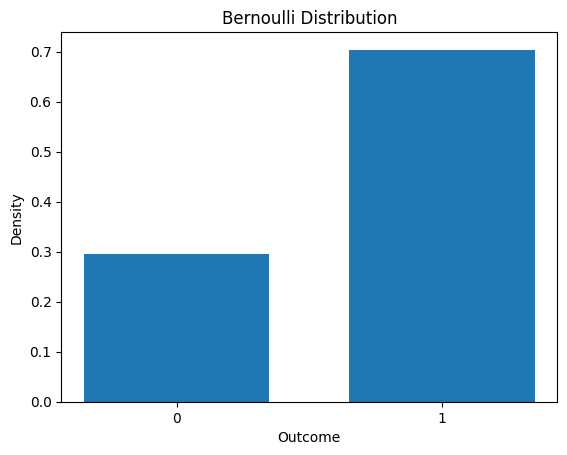

In [15]:
bernoulli_samples = np.random.binomial(1, 0.7, 1000)
plt.hist(bernoulli_samples, bins=[-0.5, 0.5, 1.5], density=True, rwidth=0.7)
plt.xticks([0, 1])
plt.xlabel('Outcome')
plt.ylabel('Density')
plt.title('Bernoulli Distribution')
plt.show()

A Bernoulli distribution models one binary event, such as a classification label or whether a customer churns.

This Binomial sample counts successes in ten repeated trials and overlays its theoretical PMF.

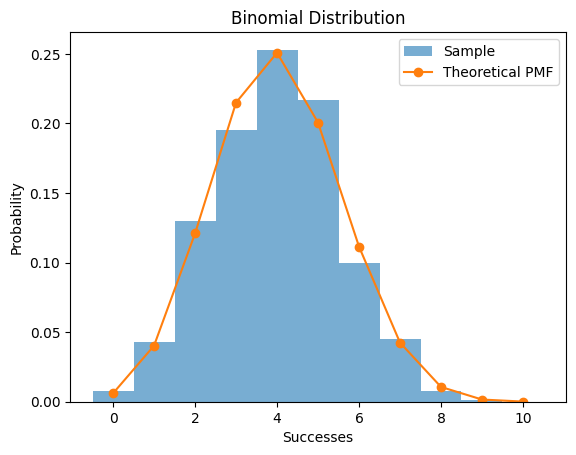

In [16]:
binomial_samples = np.random.binomial(10, 0.4, 1000)
support = np.arange(11)
plt.hist(binomial_samples, bins=np.arange(-0.5, 11.5, 1), density=True, alpha=0.6, label='Sample')
plt.plot(support, stats.binom.pmf(support, 10, 0.4), 'o-', label='Theoretical PMF')
plt.xlabel('Successes')
plt.ylabel('Probability')
plt.title('Binomial Distribution')
plt.legend()
plt.show()

A Binomial distribution models the number of successes in repeated binary trials, such as conversions across a fixed set of visits.

This Normal sample is shown with its fitted theoretical PDF.

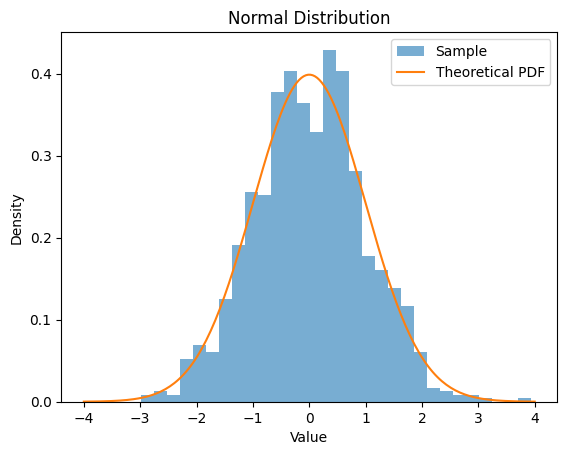

In [17]:
normal_samples = np.random.normal(0, 1, 1000)
grid = np.linspace(-4, 4, 200)
plt.hist(normal_samples, bins=30, density=True, alpha=0.6, label='Sample')
plt.plot(grid, stats.norm.pdf(grid, 0, 1), label='Theoretical PDF')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Normal Distribution')
plt.legend()
plt.show()

Normal distributions are often used to describe continuous features, initialize weights, and motivate Gaussian Naive Bayes assumptions.

## B6: Loss Functions
The following NumPy-only functions define MSE and binary cross-entropy (BCE).

In [18]:
def mse(y_true, y_pred):
    """Return mean squared error for continuous predictions."""
    return np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)

def bce(y_true, y_pred):
    """Return binary cross-entropy for probability predictions."""
    probabilities = np.clip(np.asarray(y_pred), 1e-12, 1 - 1e-12)
    targets = np.asarray(y_true)
    return -np.mean(targets * np.log(probabilities) + (1 - targets) * np.log(1 - probabilities))

Clipping probabilities prevents log(0), which is undefined and produces negative infinity. Without clipping, a model could create non-finite losses that break training.

This output demonstrates BCE for a true positive label as predictions become increasingly confidently wrong.

In [19]:
probabilities = np.array([0.9, 0.5, 0.1, 0.01])
losses = -np.log(probabilities)
for probability, loss in zip(probabilities, losses):
    print(f'y=1, predicted probability={probability:.2f}, BCE={loss:.3f}')

y=1, predicted probability=0.90, BCE=0.105
y=1, predicted probability=0.50, BCE=0.693
y=1, predicted probability=0.10, BCE=2.303
y=1, predicted probability=0.01, BCE=4.605


BCE grows sharply as a true label of 1 receives a probability near zero. This is why cross-entropy strongly discourages confident incorrect classification.

This plot shows BCE across predicted probabilities for both possible binary targets.

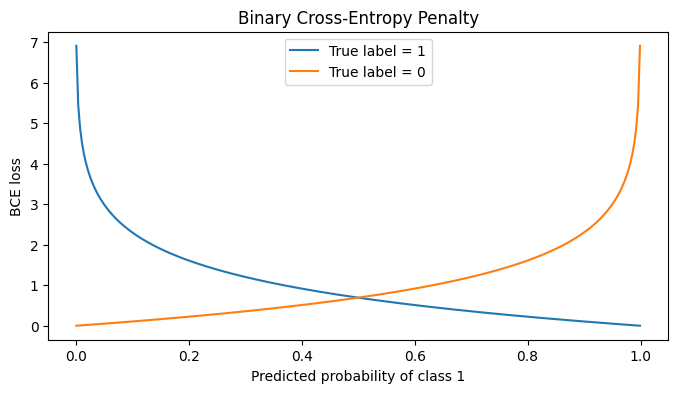

In [20]:
probability_grid = np.linspace(0.001, 0.999, 300)
plt.figure(figsize=(8, 4))
plt.plot(probability_grid, -np.log(probability_grid), label='True label = 1')
plt.plot(probability_grid, -np.log(1 - probability_grid), label='True label = 0')
plt.xlabel('Predicted probability of class 1')
plt.ylabel('BCE loss')
plt.title('Binary Cross-Entropy Penalty')
plt.legend()
plt.show()

Each curve rises near a confident prediction for the wrong class. MSE suits regression because targets are continuous and it penalizes squared distance. Cross-entropy suits classification because it evaluates probability confidence and follows Bernoulli or categorical likelihood assumptions.

This final output compares the two implemented losses on small examples.

In [21]:
print(f'MSE example: {mse([1, 2, 3], [1.2, 1.8, 3.1]):.4f}')
print(f'BCE example: {bce([1, 0, 1], [0.9, 0.2, 0.8]):.4f}')

MSE example: 0.0300
BCE example: 0.1839


The MSE value quantifies continuous prediction error, while BCE quantifies the quality of class-probability estimates. They measure different objectives and should be selected according to the prediction task.